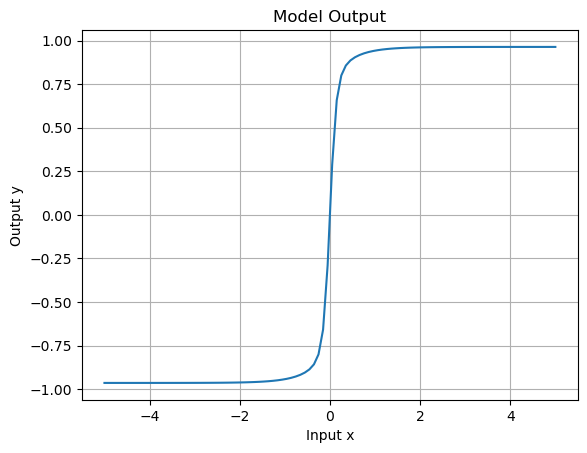

In [49]:
import numpy as np
import matplotlib.pyplot as plt

def MLP(x, w1,w2,b1,b2,W1,W2,c):
    h1 = np.tanh(x*w1 + b1)
    h2 = np.tanh(x*w2 + b2)
    y = np.tanh(h1*W1 + h2*W2 + c)
    return y

class Model:
    def __init__(self, w1, w2, b1, b2, W1, W2, c):
        self.w1 = w1
        self.w2 = w2
        self.b1 = b1
        self.b2 = b2
        self.W1 = W1
        self.W2 = W2
        self.c = c

    def __call__(self, x):
        return MLP(x, self.w1, self.w2, self.b1, self.b2, self.W1, self.W2, self.c)

def plot_model():
    x = np.linspace(-5, 5, 100)
    model = Model(1.0, -5.0, 0.0, 0.0, 1.0, -1.0, 0.0)
    y = model(x)

    plt.plot(x, y)
    plt.title('Model Output')
    plt.xlabel('Input x')
    plt.ylabel('Output y')
    plt.grid()
    plt.show()

plot_model()

In [50]:
w1 = 1.0
w2 = 1.0
W1 = 1.0
W2 = 1.0
b1 = 0.0
b2 = 0.0
c = 0.0

model = Model(w1, w2, b1, b2, W1, W2, c)

def grad(x,model, dloss:callable):
    w1 = model.w1
    w2 = model.w2
    b1 = model.b1
    b2 = model.b2
    W1 = model.W1
    W2 = model.W2
    c = model.c

    net1 = x * w1 + b1
    net2 = x * w2 + b2

    h1 = np.tanh(net1)
    h2 = np.tanh(net2)
    z = h1 * W1 + h2 * W2 + c
    y = np.tanh(z)

    def sech2(x):
        return (1 - np.tanh(x)**2)

    delta_0 = dloss(y) * sech2(z)
    xi_1 = W1 * sech2(net1)
    xi_2 = W2 * sech2(net2)
    gradients = {
        "c": delta_0,
        "W1": delta_0 * h1,
        "W2": delta_0 * h2,
        "b1": delta_0 * xi_1,
        "b2": delta_0 * xi_2,
        "w1": delta_0 * xi_1 * x,
        "w2": delta_0 * xi_2 * x
    }
    return gradients

dloss = lambda y: 1.0

x=2.0

print("Model output:", model(x), 0.9092516739969425)

grad(x, model, dloss)


Model output: 0.9585759101766381 0.9092516739969425


{'c': 0.08113222442902979,
 'W1': 0.07821370198248566,
 'W2': 0.07821370198248566,
 'b1': 0.005732058578083012,
 'b2': 0.005732058578083012,
 'w1': 0.011464117156166024,
 'w2': 0.011464117156166024}

In [51]:
import torch

from torch import nn

class MLP(nn.Module):
    def __init__(self, layer_dims=[1,2,1], activation="tanh"):
        super().__init__()
        self.input_dim = layer_dims[0]
        self.output_dim = layer_dims[-1]
        self.hidden_dims = layer_dims[1:-1]
        self.activation = activation

        layers = []
        for i in range(len(layer_dims) - 1):
            layers.append(nn.Linear(layer_dims[i], layer_dims[i+1]))
            if i < len(layer_dims) - 1:  # Adding activation function for all layers except the last lasyer
                if activation == "relu":
                    layers.append(nn.ReLU())
                elif activation == "tanh":
                    layers.append(nn.Tanh())
                elif activation == "sigmoid":
                    layers.append(nn.Sigmoid())

        self.model = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.model(x)
print(MLP())

MLP(
  (model): Sequential(
    (0): Linear(in_features=1, out_features=2, bias=True)
    (1): Tanh()
    (2): Linear(in_features=2, out_features=1, bias=True)
    (3): Tanh()
  )
)


In [52]:
def loss(x):
    return x

from pprint import pprint

torch.set_default_dtype(torch.float64)
torch.set_printoptions(precision=16)

model = MLP()

# init_weights with 1 in weights and 0 in biases
def init_weights(model):
    for layer in model.model:
        if isinstance(layer, nn.Linear):
            nn.init.constant_(layer.weight, 1.0)
            nn.init.constant_(layer.bias, 0.0)
init_weights(model)

print("Model output:", model(torch.tensor([1.0])), 0.9092516739969425)
def grad_torch(x, model, dloss):
    x = torch.tensor(x, requires_grad=True).view(-1, 1)  # Reshape to match input dimension
    print(x.shape)
    y = model(x)
    print(y)

    def grad_vector(model, x_vec):
        gradients_list = []
        for x in x_vec:
            x_tensor = torch.tensor(x, requires_grad=True).view(-1, 1)
            y = model(x_tensor)
            loss_value = dloss(y)
            loss_value.backward()
            gradients = {}
            for name, param in model.named_parameters():
                gradients[name] = param.grad
            # Reset gradients to zero for the next iteration
            for param in model.parameters():
                param.grad = None
            gradients_list.append(gradients)
        return gradients_list

    grads = grad_vector(model, x)
    print("Gradients:\n")
    pprint(grads)
    # loss_value.backward()
    
    gradients = {}
    for name, param in model.named_parameters():
        gradients[name] = param.grad
    # gradients = {
    #     "w1": model.model[0].weight.grad,
    #     "b1": model.model[0].bias.grad,
    #     "w2": model.model[2].weight.grad,
    #     "b2": model.model[2].bias.grad,
    #     "W1": model.model[4].weight.grad,
    #     "W2": model.model[6].weight.grad,
    #     "c": model.model[8].bias.grad
    # }
    return gradients

x_vec = [1.,2.,3.,4.,5.,6.,7.,8.]

grad_torch(x_vec, model, loss)

Model output: tensor([0.9092516739969425], grad_fn=<TanhBackward0>) 0.9092516739969425
torch.Size([8, 1])
tensor([[0.9092516739969425],
        [0.9585759101766381],
        [0.9633221051195399],
        [0.9639326863678813],
        [0.9640147482421459],
        [0.9640258436706625],
        [0.9640273450824992],
        [0.9640275482729950]], grad_fn=<TanhBackward0>)
Gradients:

[{'model.0.bias': tensor([0.0727653395924737, 0.0727653395924737]),
  'model.0.weight': tensor([[0.0727653395924737],
        [0.0727653395924737]]),
  'model.2.bias': tensor([0.1732613933337578]),
  'model.2.weight': tensor([[0.1319548646157430, 0.1319548646157430]])},
 {'model.0.bias': tensor([0.0057320585780830, 0.0057320585780830]),
  'model.0.weight': tensor([[0.0114641171561660],
        [0.0114641171561660]]),
  'model.2.bias': tensor([0.0811322244290298]),
  'model.2.weight': tensor([[0.0782137019824857, 0.0782137019824857]])},
 {'model.0.bias': tensor([0.0007104584842637, 0.0007104584842637]),
  'mod

/tmp/ipykernel_4584/2390721218.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_tensor = torch.tensor(x, requires_grad=True).view(-1, 1)


{'model.0.weight': None,
 'model.0.bias': None,
 'model.2.weight': None,
 'model.2.bias': None}

In [ ]:
import torch
from torch import nn
from torch.func import functional_call, vmap, grad
from pprint import pprint

# Use high precision
torch.set_default_dtype(torch.float64)
torch.set_printoptions(precision=16)

# Initialize model with weights=1, biases=0
def init_weights(model):
    for layer in model.model:
        if isinstance(layer, nn.Linear):
            nn.init.constant_(layer.weight, 1.0)
            nn.init.constant_(layer.bias, 0.0)

# Loss function: identity or log
def dloss(y):
    return y  # or torch.log(y)

# Vectorized gradient function
def grad_torch(x_vec, model, dloss):
    if not isinstance(x_vec, torch.Tensor):
        x_tensor = torch.tensor(x_vec, dtype=torch.get_default_dtype()).view(-1, 1)
    else:
        x_tensor = x_vec.view(-1, 1)

    # Extract parameter values and structure
    params = dict(model.named_parameters())

    def loss_fn(params, x):
        y = functional_call(model, params, (x.view(1, -1),))  # Single input
        return dloss(y).squeeze()

    # Compute per-example grads (vectorized)
    per_example_grads = vmap(grad(loss_fn), in_dims=(None, 0))(params, x_tensor)

    print("Per-example gradients:\n")
    pprint(per_example_grads)
    
    # Format output
    grads_by_example = []
    for i in range(len(x_vec)):
        grads_i = {name: tensor[i] for name, tensor in per_example_grads.items()}
        grads_by_example.append(grads_i)

    print("number of gradients:\n")
    pprint(len(grads_by_example))
    return grads_by_example

# Example usage
model = MLP()
init_weights(model)
x_vec = np.linspace(1.0, 5.0, 3)

print("Model output:", model(torch.tensor([1.0])), 0.9092516739969425)
grad_torch(x_vec, model, dloss);

Model output: tensor([0.9092516739969425], grad_fn=<TanhBackward0>) 0.9092516739969425
Per-example gradients:

{'model.0.bias': tensor([[7.2765339592473749e-02, 7.2765339592473749e-02],
        [7.1045848426372100e-04, 7.1045848426372100e-04],
        [1.2833497472647758e-05, 1.2833497472647758e-05]],
       grad_fn=<ViewBackward0>),
 'model.0.weight': tensor([[[7.2765339592473749e-02],
         [7.2765339592473749e-02]],

        [[2.1313754527911631e-03],
         [2.1313754527911631e-03]],

        [[6.4167487363238793e-05],
         [6.4167487363238793e-05]]], grad_fn=<TransposeBackward0>),
 'model.2.bias': tensor([[0.1732613933337578],
        [0.0720105217880582],
        [0.0706755651716320]], grad_fn=<ViewBackward0>),
 'model.2.weight': tensor([[[0.1319548646157430, 0.1319548646157430]],

        [[0.0716544120206692, 0.0716544120206692]],

        [[0.0706691481315757, 0.0706691481315757]]],
       grad_fn=<TransposeBackward0>)}
number of gradients:

3


In [62]:
class MLPwithGradients(nn.Module):
    def __init__(self, layer_dims=[1,2,1], activation="tanh"):
        super().__init__()
        self.input_dim = layer_dims[0]
        self.output_dim = layer_dims[-1]
        self.hidden_dims = layer_dims[1:-1]
        self.activation = activation

        layers = []
        for i in range(len(layer_dims) - 1):
            layers.append(nn.Linear(layer_dims[i], layer_dims[i+1]))
            if i < len(layer_dims) - 1:  # Adding activation function for all layers except the last layer
                if activation == "relu":
                    layers.append(nn.ReLU())
                elif activation == "tanh":
                    layers.append(nn.Tanh())
                elif activation == "sigmoid":
                    layers.append(nn.Sigmoid())
        self.model = nn.Sequential(*layers)

    def grad(self,x:torch.Tensor=None, log: bool = False):
        if x is None:
            raise ValueError("No samples provided for gradient computation.")
        
        y = self.model(x)
        params = dict(self.model.named_parameters())

        def loss_fn(x):
            return torch.log(y) if log else y

        per_sample_gradients = vmap(grad(loss_fn), in_dims=(None, 0))(params, x)

        gradients_dict = {name: grad for name, grad in zip(self.model.state_dict().keys(), per_sample_gradients)}
        return gradients_dict
    def forward(self, x):
        return self.model(x)
    
model = MLPwithGradients()
init_weights(model)
x_vec = torch.tensor(np.linspace(1.0, 5.0, 3), dtype=torch.get_default_dtype()).view(-1, 1)
print("Model output:", model(torch.tensor([1.0])), 0.9092516739969425)
gradients = model.grad(x_vec, log=False)
print("Gradients:\n")
pprint(gradients)


Model output: tensor([0.9092516739969425], grad_fn=<TanhBackward0>) 0.9092516739969425


TypeError: MLPwithGradients.grad.<locals>.loss_fn() takes 1 positional argument but 2 were given